In [1]:
!pip install -U langgraph langchain langchain-google-genai dotenv langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.0 MB/s eta 0:00:00
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.13
    Uninstalling langchain-1.3.13:
      Successfully uninstalled langchain-1.3.13


In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [19]:
from google.colab import userdata
groq_api_key = userdata.get("GROQ_API_KEY")

In [11]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):

  messages: Annotated[list[BaseMessage], add_messages]

In [21]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=groq_api_key,
)

def chat_node(state: ChatState) -> ChatState:

  # Take user query
  messages = state['messages']

  # Send to LLM
  response = llm.invoke(messages)

  # Response Store State
  return {'messages': [response]}

In [29]:
graph = StateGraph(ChatState)

# Add Node
graph.add_node('chat_node', chat_node)

# Add Edge
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

workflow = graph.compile()

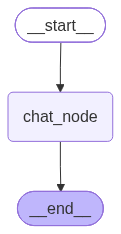

In [25]:
workflow

In [31]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of India?')]
}
response = workflow.invoke(initial_state)
print("Response is : ", response['messages'][1].content)

Response is :  The capital of India is New Delhi.
